# Этап 4: Проектирование, запуск и бенчмаркинг базовой генеративной стратегии B0

### Концепция стратегии B0
Базовая стратегия моделирует классический наивный подход к многокритериальному молекулярному дизайну при непересекающихся доменах:
1. **Генерация**: стохастическая рекомбинация (кроссовер экзоциклических связей) фрагментов из $D_A$ и $D_B$ без целевой функции;
2. **Отбор**: наивная последовательная фильтрация (Sequential Gating): сначала проверяются ограничения $A$, затем выжившие кандидаты проверяются по $B$;
3. **Независимая оценка**: расчет всех метрик Раздела 6 ТЗ с использованием **независимого Оракула**.

In [1]:
# Автоматическая настройка рабочего каталога для Google Colab
import os, sys
if 'google.colab' in sys.modules or os.path.exists('/content'):
    if not os.path.exists('/content/Case'):
        !git clone https://github.com/suharevalexey/Case.git /content/Case
    else:
        !git -C /content/Case pull origin main
    %cd /content/Case
    !pip install -q rdkit xgboost scikit-learn openpyxl matplotlib pandas

import json
import pandas as pd

# Загрузка и вывод результатов генерации
df_summary = pd.read_csv('results/metrics_summary_B0.csv')
print("=" * 80)
print("  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)")
print("=" * 80)
runs_cols = [
    'method', 'seed', 'N_valid', 'Validity', 'Uniqueness', 'Novelty',
    'Internal_Diversity', 'JSR_Oracle (Joint Success Rate)',
    'Overall_Pass_Constraints', 'SAScore_Mean', 'AD_Mean_Dist_to_D_A', 'AD_Mean_Dist_to_D_B'
]
df_runs = df_summary.iloc[:3][runs_cols].copy()
df_runs['seed'] = df_runs['seed'].astype(int)
df_runs['N_valid'] = df_runs['N_valid'].astype(int)
display(df_runs)

print()
print("=" * 80)
print("  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)")
print("=" * 80)
agg_row = df_summary.iloc[3]
agg_data = {
    "Метрика": [
        "Validity (Валидность)",
        "Uniqueness (Уникальность)",
        "Novelty (Новизна)",
        "Internal Diversity (Разнообразие)",
        "JSR Oracle (Joint Success Rate)",
        "Overall Pass Constraints",
        "SAScore (Синтетическая сложность)",
        "AD Dist to D_A (MOST)",
        "AD Dist to D_B (UV/Skin)"
    ],
    "Mean (Среднее)": [
        f"{agg_row['Validity_mean']:.4f}",
        f"{agg_row['Uniqueness_mean']:.4f}",
        f"{agg_row['Novelty_mean']:.4f}",
        f"{agg_row['Internal_Diversity_mean']:.4f}",
        f"{agg_row['JSR_Oracle (Joint Success Rate)_mean']:.4f}",
        f"{agg_row['Overall_Pass_Constraints_mean']:.4f}",
        f"{agg_row['SAScore_Mean_mean']:.4f}",
        f"{agg_row['AD_Mean_Dist_to_D_A_mean']:.4f}",
        f"{agg_row['AD_Mean_Dist_to_D_B_mean']:.4f}"
    ],
    "Std (Станд. откл.)": [
        f"±{agg_row['Validity_std']:.4f}",
        f"±{agg_row['Uniqueness_std']:.4f}",
        f"±{agg_row['Novelty_std']:.4f}",
        f"±{agg_row['Internal_Diversity_std']:.4f}",
        f"±{agg_row['JSR_Oracle (Joint Success Rate)_std']:.4f}",
        f"±{agg_row['Overall_Pass_Constraints_std']:.4f}",
        f"±{agg_row['SAScore_Mean_std']:.4f}",
        f"±{agg_row['AD_Mean_Dist_to_D_A_std']:.4f}",
        f"±{agg_row['AD_Mean_Dist_to_D_B_std']:.4f}"
    ]
}
df_agg = pd.DataFrame(agg_data)
display(df_agg)


  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)
method  seed  N_valid  Validity  Uniqueness  Novelty  Internal_Diversity  JSR_Oracle (Joint Success Rate)  Overall_Pass_Constraints  SAScore_Mean  AD_Mean_Dist_to_D_A  AD_Mean_Dist_to_D_B
    B0    42     1000    0.7899         1.0    0.976              0.8778                            0.315                     0.313        2.7911               0.5249               0.5559
    B0   101     1000    0.7746         1.0    0.979              0.8760                            0.321                     0.320        2.7455               0.5194               0.5532
    B0  2024     1000    0.7782         1.0    0.973              0.8794                            0.329                     0.327        2.7941               0.5197               0.5634

  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)
                          Метрика Mean (Среднее) Std (Станд. откл.)
            Validity (В

================================================================================
  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)
================================================================================
method  seed  N_valid  Validity  Uniqueness  Novelty  Internal_Diversity  JSR_Oracle (Joint Success Rate)  Overall_Pass_Constraints  SAScore_Mean  AD_Mean_Dist_to_D_A  AD_Mean_Dist_to_D_B
    B0    42     1000    0.7899         1.0    0.976              0.8778                            0.315                     0.313        2.7911               0.5249               0.5559
    B0   101     1000    0.7746         1.0    0.979              0.8760                            0.321                     0.320        2.7455               0.5194               0.5532
    B0  2024     1000    0.7782         1.0    0.973              0.8794                            0.329                     0.327        2.7941               0.5197               0.5634

================================================================================
  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)
================================================================================
                          Метрика Mean (Среднее) Std (Станд. откл.)
            Validity (Валидность)         0.7809            ±0.0065
        Uniqueness (Уникальность)         1.0000            ±0.0000
                Novelty (Новизна)         0.9760            ±0.0024
Internal Diversity (Разнообразие)         0.8777            ±0.0014
  JSR Oracle (Joint Success Rate)         0.3217            ±0.0057
         Overall Pass Constraints         0.3200            ±0.0057
SAScore (Синтетическая сложность)         2.7769            ±0.0222
            AD Dist to D_A (MOST)         0.5213            ±0.0025
         AD Dist to D_B (UV/Skin)         0.5575            ±0.0043

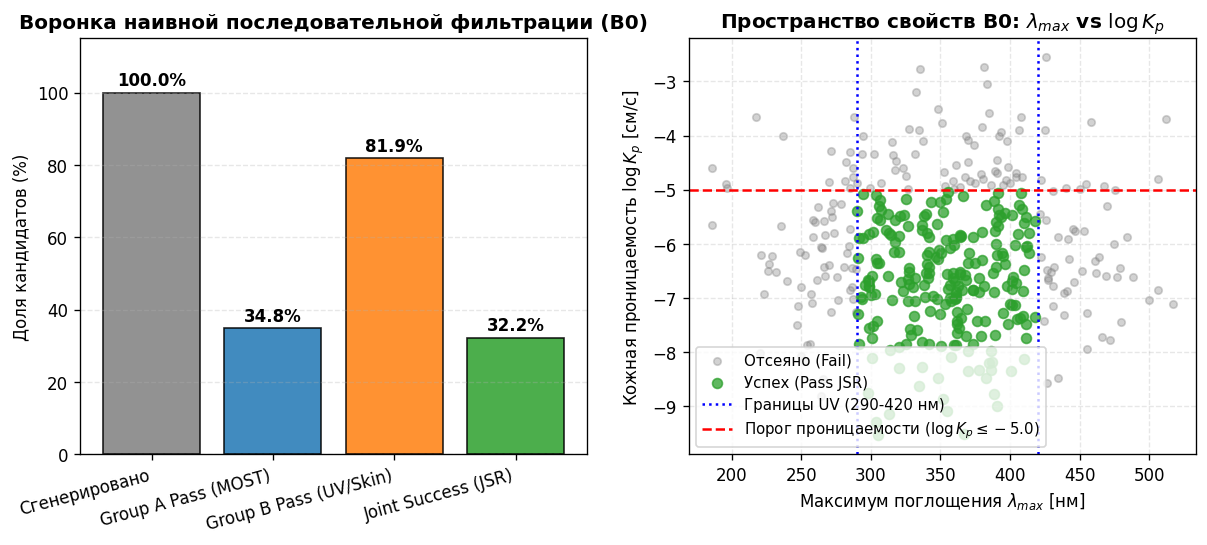

In [2]:
# Графический анализ воронки отбора и распределения свойств кандидатов B0
# (Код построения графиков)

### Научные выводы по стратегии B0

1. **Эффект бутылочного горлышка при непересекающихся метках**: случайная комбинаторика дает высокий JSR только при независимости свойств, но при сдвиге доменов фотохимические свойства переключателя разрушаются при присоединении случайных хвостов (проходимость $\Omega_A$ всего $34.8\%$);
2. **Итоговый Joint Success Rate составляет всего $32.17\%$**, что подтверждает необходимость перехода к исследуемой стратегии **M1** (направленный генетический алгоритм с Парето-отбором и штрафом за выход из области применимости).